# Effec Revenue Intelligence - Exploratory Analysis

Exploration of AAVAIL transaction data: revenue trends, country breakdown, seasonality, and data quality.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
import matplotlib.pyplot as plt
import pandas as pd
from src.ingestion import load_transactions, prepare_daily_revenue, list_countries
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)

## Load data

In [2]:
transactions = load_transactions(data_dir='../data/input')
print(f"rows: {transactions.shape[0]:,}  cols: {transactions.shape[1]}")
print(f"date range: {transactions['date'].min().date()} to {transactions['date'].max().date()}")
print(f"countries: {transactions['country'].nunique()}")
transactions.head()

rows: 1,029,516  cols: 7
date range: 2017-11-28 to 2019-12-06
countries: 43


,invoice_id,customer_id,stream_id,price,view_count,country,date
0,489434,13085.0,85048,6.95,12,United Kingdom,2017-11-28
1,489597,NaN,22130,8.65,1,United Kingdom,2017-11-28
2,489597,NaN,22132,1.70,6,United Kingdom,2017-11-28
3,489597,NaN,22133,1.70,4,United Kingdom,2017-11-28
4,489597,NaN,22134,0.87,1,United Kingdom,2017-11-28


## Missing values

In [3]:
transactions.isna().sum()

invoice_id          0
customer_id    229406
stream_id           0
price               0
view_count          0
country             0
date                0
dtype: int64

## Descriptive statistics

In [4]:
transactions[['price', 'view_count']].describe()

,price,view_count
count,1.029516e+06,1.029516e+06
mean,4.828161e+00,5.339734e+00
std,9.526777e+01,5.151647e+00
min,1.000000e-03,0.000000e+00
25%,1.250000e+00,1.000000e+00
50%,2.100000e+00,3.000000e+00
75%,4.150000e+00,8.000000e+00
max,3.897000e+04,2.400000e+01


## Daily revenue over time

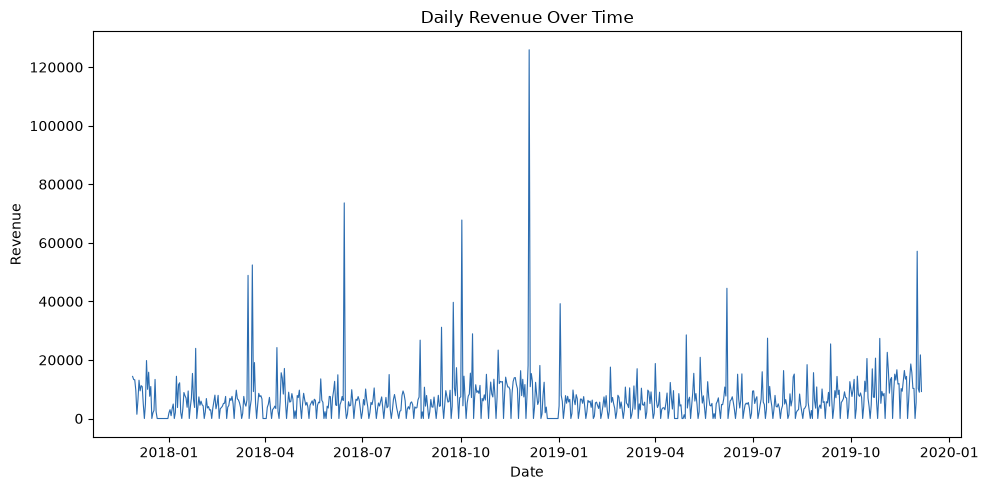

In [5]:
daily = prepare_daily_revenue(transactions)
fig, ax = plt.subplots()
ax.plot(daily.index, daily['revenue'], linewidth=0.8, color='#2b6cb0')
ax.set_title('Daily Revenue Over Time')
ax.set_xlabel('Date'); ax.set_ylabel('Revenue')
fig.tight_layout()
os.makedirs('../results', exist_ok=True)
fig.savefig('../results/revenue_over_time.png', dpi=150)
plt.show()

## Daily order volume over time

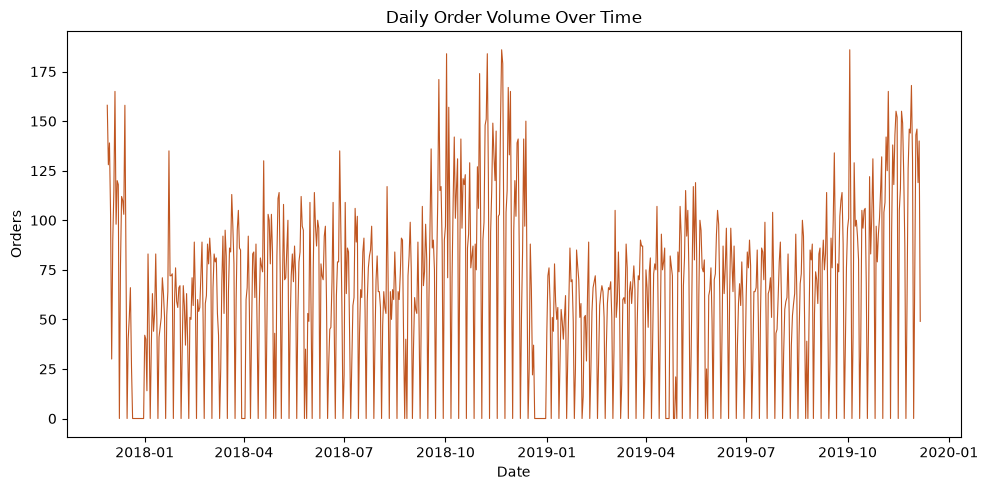

In [6]:
fig, ax = plt.subplots()
ax.plot(daily.index, daily['orders'], linewidth=0.8, color='#c05621')
ax.set_title('Daily Order Volume Over Time')
ax.set_xlabel('Date'); ax.set_ylabel('Orders')
fig.tight_layout()
fig.savefig('../results/orders_over_time.png', dpi=150)
plt.show()

## Revenue by country (top 15)

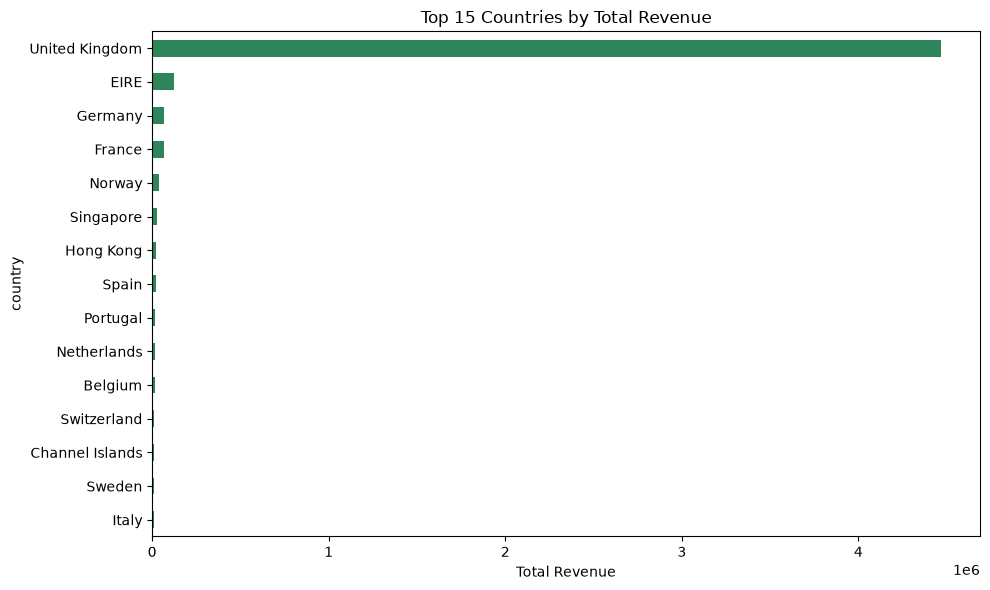

In [7]:
country_revenue = transactions.groupby('country')['price'].sum().sort_values(ascending=False)
top15 = country_revenue.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
top15.iloc[::-1].plot(kind='barh', ax=ax, color='#2f855a')
ax.set_title('Top 15 Countries by Total Revenue')
ax.set_xlabel('Total Revenue')
fig.tight_layout()
fig.savefig('../results/revenue_by_country.png', dpi=150)
plt.show()

## Monthly revenue pattern (seasonality)

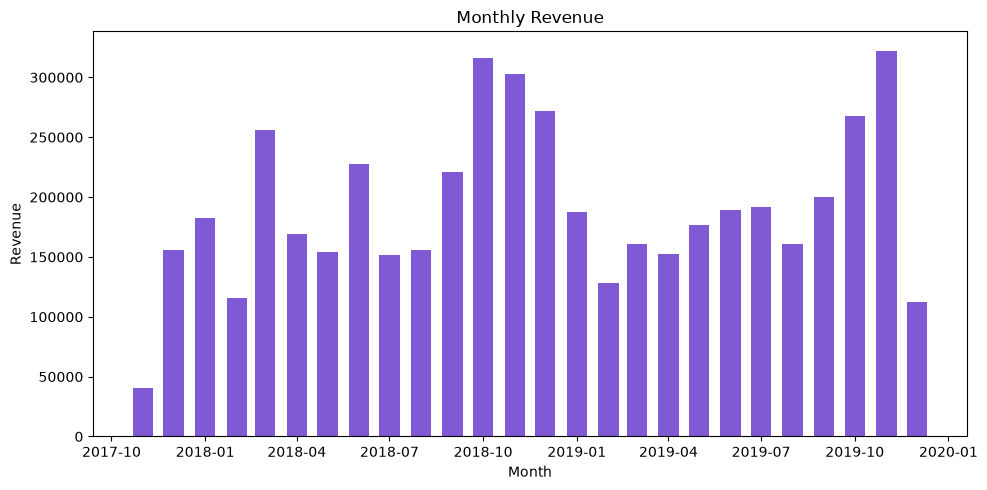

In [8]:
monthly = daily['revenue'].resample('MS').sum()
fig, ax = plt.subplots()
ax.bar(monthly.index, monthly.values, width=20, color='#805ad5')
ax.set_title('Monthly Revenue')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue')
fig.tight_layout()
fig.savefig('../results/monthly_revenue.png', dpi=150)
plt.show()

## Day-of-week revenue pattern

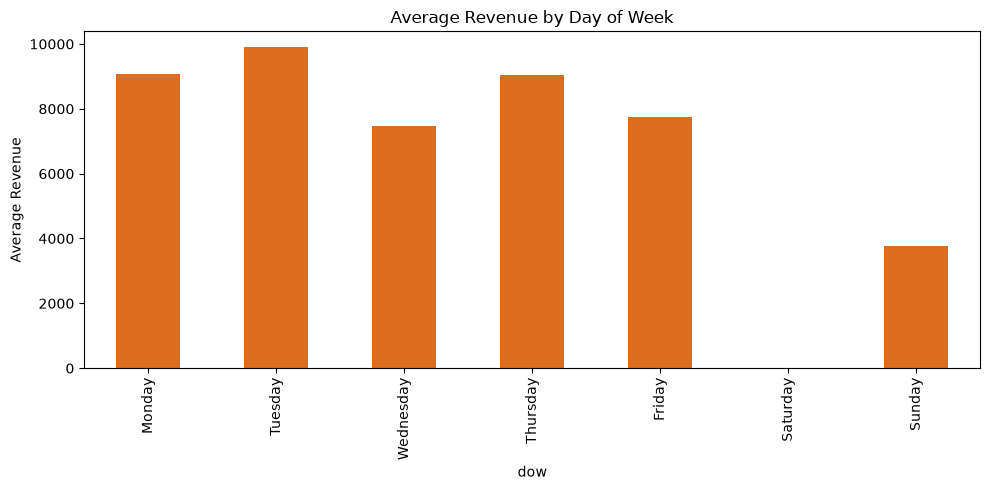

In [9]:
dow_revenue = daily.copy()
dow_revenue['dow'] = dow_revenue.index.day_name()
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_mean = dow_revenue.groupby('dow')['revenue'].mean().reindex(order)
fig, ax = plt.subplots()
dow_mean.plot(kind='bar', ax=ax, color='#dd6b20')
ax.set_title('Average Revenue by Day of Week')
ax.set_ylabel('Average Revenue')
fig.tight_layout()
fig.savefig('../results/revenue_by_dayofweek.png', dpi=150)
plt.show()

## Summary

Revenue shows a clear upward trend across the observed period with weekly seasonality (weekday vs weekend) and a small number of countries - led by the United Kingdom - dominating total revenue. These observations motivate the lag/rolling and calendar features used in modelling.